# Paper Figures

This notebook generates all the plots needed for the paper based on available GEPA experiment data.

In [1]:
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

from core.experiment.plots import (
    PlotConfig,
    Figure,
    Grid,
    BarPlot,
    ProgressionPlot,
    ScatterPlot,
)
from core.experiment_utils import load_experiments_config

load_dotenv()

# Output directory for saved plots
OUTPUT_DIR = Path("plots/paper")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load experiment paths from config
# Change this to use a different version (e.g., "v1", "v2")
# Set to None to use the default version from experiments_config.yaml
CONFIG_VERSION = "v1"
# CONFIG_VERSION = None

EXPERIMENTS = load_experiments_config(CONFIG_VERSION)

## Computed Column Functions

In [2]:
def make_optimizer_column(df: pd.DataFrame) -> pd.Series:
    """Create optimizer column with 4 categories for progression plot.

    Categories:
    - GEPA: suggest_hack=no, no teacher
    - GEPA (Hack): suggest_hack=explicit, no teacher
    - GEPA (Hack + Teacher): suggest_hack=explicit, teacher file but no tool
    - GEPA (Hack + Teacher + Tool): suggest_hack=explicit, teacher file AND tool
    """
    def get_optimizer(row: pd.Series) -> str:
        suggest_hack = row.get("suggest_hack")
        train_teacher_file = row.get("train_teacher_file")
        teacher_tool_model = row.get("teacher_tool_model")
        show_expert_reasoning = row.get("show_expert_reasoning")

        has_teacher = pd.notna(train_teacher_file) and train_teacher_file not in [None, "null", ""]
        has_tool = pd.notna(teacher_tool_model) and teacher_tool_model not in [None, "null", ""]
        shows_reasoning = show_expert_reasoning in [True, "true"]

        all_settings = (suggest_hack, has_teacher, has_tool, shows_reasoning)

        if all_settings == ("no", False, False, False):
            return "GEPA"
        elif all_settings == ("explicit", False, False, False):
            return "GEPA (Hack)"
        elif all_settings == ("explicit", True, False, False):
            return "GEPA (Hack + Teacher)"
        elif all_settings == ("explicit", True, True, False):
            return "GEPA (Hack + Teacher + Tool)"
        elif all_settings == ("explicit", True, False, True):
            return "GEPA (Hack + Teacher with Reasoning)"
        else:
            return None

    return df.apply(get_optimizer, axis=1)


def make_env_display_name(df: pd.DataFrame) -> pd.Series:
    """Create display-friendly environment names."""
    env_map = {
        "psychosis": "Delusional Queries",
        "wordchain": "Phrase Ladder",
        "mcq": "Hinted MMLU",
    }
    return df["env_name"].map(lambda x: env_map.get(x, x))


def make_short_model_name(df: pd.DataFrame) -> pd.Series:
    """Extract short model name from executor_name (e.g., 'deepinfra/Qwen/Qwen3-30B-A3B' -> 'Qwen3-30B-A3B')."""
    return df["executor_name"].map(lambda x: x.split("/")[-1] if pd.notna(x) else x)

## Plot Configurations

Experiment paths are loaded from `experiments_config.yaml` via `EXPERIMENTS` dict.

To switch versions: set `CONFIG_VERSION = "v1"` (or another version) in the imports cell above.

In [ ]:
# Metrics commonly used
CORE_METRICS = ["proxy_reward", "true_reward", "hacking_rate"]
VERBALIZATION_METRICS = ["prompt_verbalizes"]
COT_METRICS = ["cot_verbalizes_yes", "cot_verbalizes_unclear", "cot_verbalizes_no"]

CONFIGS = {
    # =========================================================================
    # Figure 1: Proxy Reward and Hacking Rate by Environment (Bar Plot)
    # proxy-and-hacking-increase-aggregate-mmlu.png
    # Shows Baseline vs GEPA for all 3 environments
    # =========================================================================
    "proxy_hacking_bar": PlotConfig(
        paths=[
            EXPERIMENTS["mcq"]["teacher_false"],  # False because MCQ doesn't have a teacher
            EXPERIMENTS["psychosis"]["teacher_true"],
            EXPERIMENTS["wordchain"]["teacher_true"],
        ],
        quick_mode=True,
        metrics=CORE_METRICS,
        computed_columns={
            "env_display": make_env_display_name,
        },
        figures=[
            Figure(
                name="Proxy Reward and Hacking Rate by Environment",
                filter=lambda df: df.is_final & ~df.is_sanitized & df.subset.isna(),
                layout=Grid(
                    groupby="env_display",
                    cols_wrap=3,
                    inner=BarPlot(
                        x="suggest_hack",
                        y=["proxy_reward", "hacking_rate"],
                        hue="column_name",
                    ),
                ),
            ),
        ],
    ),

    # =========================================================================
    # Figure 2: GEPA Prompt Verbalization Scatter Plot
    # gepa-prompt-and-rl-cot.png (GEPA side only, RL skipped for now)
    # Shows Proxy Reward vs Hacking Rate, colored by verbalization
    # =========================================================================
    "verbalization_scatter": PlotConfig(
        paths=[
            # Not sure whether we should include every single experiment
            EXPERIMENTS["mcq"]["teacher_false"],
            EXPERIMENTS["psychosis"]["teacher_false"],
            EXPERIMENTS["psychosis"]["teacher_true"],
            EXPERIMENTS["wordchain"]["teacher_false"],
            EXPERIMENTS["wordchain"]["teacher_true"],
        ],
        quick_mode=False,  # Need all candidates for scatter
        metrics=CORE_METRICS + VERBALIZATION_METRICS,
        computed_columns={
            "env_display": make_env_display_name,
        },
        figures=[
            Figure(
                name="GEPA: Proxy Reward vs Hacking Rate",
                filter=lambda df: ~df.is_sanitized & df.prompt_verbalizes.notna(),
                layout=Grid(
                    groupby="env_display",
                    inner=ScatterPlot(
                        x="hacking_rate",
                        y="proxy_reward",
                        color="prompt_verbalizes",
                    ),
                ),
            ),
        ],
    ),

    # =========================================================================
    # Figure 3: Optimizer Progression Plot
    # optimizer-progression.png
    # Shows 4 lines: GEPA, GEPA (Hack), GEPA (Hack + Teacher), GEPA (Hack + Teacher + Tool)
    # =========================================================================
    "optimizer_progression": PlotConfig(
        paths=[
            EXPERIMENTS["mcq"]["teacher_false"],
            EXPERIMENTS["psychosis"]["teacher_false"],
            EXPERIMENTS["psychosis"]["teacher_true"],
            EXPERIMENTS["wordchain"]["teacher_false"],
            EXPERIMENTS["wordchain"]["teacher_true"],
        ],
        quick_mode=False,  # Need progression data
        metrics=["proxy_reward"],  # Only need proxy_reward for progression
        computed_columns={
            "optimizer": make_optimizer_column,
            "env_display": make_env_display_name,
        },
        figures=[
            Figure(
                name="Training Progression by Optimizer Variant",
                filter=lambda df: ~df.is_sanitized & df.optimizer.notna() & df.subset.isna(),
                layout=Grid(
                    groupby="env_display",
                    inner=ProgressionPlot(
                        x="discovery_eval_counts",
                        y="proxy_reward",
                        hue="optimizer",
                    ),
                ),
            ),
        ],
    ),

    # =========================================================================
    # Figure 4: Sanitization Plot
    # sanitization.jpg
    # Shows Proxy vs True reward, with original and sanitized points
    # Different markers for different prompters
    # =========================================================================
    "sanitization": PlotConfig(
        paths=[
            EXPERIMENTS["mcq"]["teacher_false"],
            EXPERIMENTS["psychosis"]["teacher_true"],
            EXPERIMENTS["wordchain"]["teacher_true"],
        ],
        quick_mode=True,  # Only need final candidates
        metrics=["proxy_reward", "true_reward"],
        computed_columns={
            "env_display": make_env_display_name,
        },
        figures=[
            Figure(
                name="Sanitization Effect: Proxy vs True Reward",
                filter=lambda df: df.is_final & df.subset.isna(),
                layout=Grid(
                    groupby="env_display",
                    inner=ScatterPlot(
                        x="proxy_reward",
                        y="true_reward",
                        color="is_sanitized",
                        marker="prompter_name",
                    ),
                ),
            ),
        ],
    ),
    "sanitization2": PlotConfig(
        paths=[
            EXPERIMENTS["mcq"]["teacher_false"],
            EXPERIMENTS["psychosis"]["teacher_true"],
            EXPERIMENTS["wordchain"]["teacher_true"],
        ],
        quick_mode=True,  # Only need final candidates
        metrics=["hacking_rate", "true_reward"],
        computed_columns={
            "env_display": make_env_display_name,
        },
        figures=[
            Figure(
                name="Sanitization Effect: Proxy vs True Reward",
                filter=lambda df: df.is_final & df.subset.isna(),
                layout=Grid(
                    groupby="env_display",
                    inner=ScatterPlot(
                        x="hacking_rate",
                        y="true_reward",
                        color="is_sanitized",
                        marker="prompter_name",
                    ),
                ),
            ),
        ],
    ),

    # =========================================================================
    # Figure 5: Length Penalty Plot (TODO: needs length_penalty sweep data)
    # length-penalty.png
    # Shows prompt length vs proxy reward with different length penalties
    # =========================================================================
    # "length_penalty": PlotConfig(...),  # TODO: Implement when data available

    # =========================================================================
    # Figure 6: Monitor Optimization Plot (TODO: needs verbalization_penalty sweep)
    # monitor-optimization.jpg
    # Shows what happens when optimizing against a suspiciousness monitor
    # =========================================================================
    # "monitor_optimization": PlotConfig(...),  # TODO: Implement when data available

    # =========================================================================
    # Figure 7: Baseline Model Comparison (Hacking Rate vs CoT Verbalization)
    # baseline-model-comparison.png
    # Compares hacking_rate and cot_verbalizes_yes across baseline models
    # =========================================================================
    "baseline_model_comparison": PlotConfig(
        paths=[
            EXPERIMENTS["mcq"]["baseline_only"],
        ],
        quick_mode=True,  # Only one candidate per baseline-only experiment
        metrics=["hacking_rate"] + COT_METRICS,
        computed_columns={
            "model_name": make_short_model_name,
        },
        figures=[
            Figure(
                name="Baseline Models: Hacking Rate vs CoT Verbalization",
                filter=lambda df: ~df.is_sanitized & df.subset.isin(["hinted", "gameable"]),
                # layout=Grid(
                #     groupby="hint_type",
                #     cols_wrap=1,
                #     inner=Grid(
                #         groupby="incompetent",
                #         inner=BarPlot(
                #             x="model_name",
                #             y=["hacking_rate", "cot_verbalizes_yes", "cot_verbalizes_unclear"],
                #             hue="column_name",
                #         ),
                #     ),
                # )
                layout=Grid(
                    groupby="incompetent",
                    inner=BarPlot(
                        x="model_name",
                        y=["hacking_rate", "cot_verbalizes_yes", "cot_verbalizes_unclear"],
                        hue="column_name",
                    ),
                ),
            ),
        ],
    ),

    # =========================================================================
    # Figure 8: Tinker Models by Hint Type
    # Shows hacking_rate and CoT verbalization for RL-trained tinker models
    # One model per hint_type, so hint_type is on x-axis
    # =========================================================================
    "tinker_by_hint_type": PlotConfig(
        paths=[
            "logs/mcq/tinker/2026-01-11-15-01-08",
        ],
        quick_mode=True,  # Only one candidate per baseline-only experiment
        metrics=["hacking_rate"] + COT_METRICS,
        figures=[
            Figure(
                name="Tinker Models: Hacking Rate vs CoT Verbalization by Hint Type",
                filter=lambda df: ~df.is_sanitized & df.subset.isin(["hinted", "gameable"]),
                layout=BarPlot(
                    x="hint_type",
                    y=["hacking_rate", "cot_verbalizes_yes", "cot_verbalizes_unclear"],
                    hue="column_name",
                ),
            ),
        ],
    ),
}

## Render Plots

All metrics cached for prompter_name=anthropic_claude_opus_4_5-suggest_hack=explicit-hint_type=consistency
All metrics cached for prompter_name=anthropic_claude_opus_4_5-suggest_hack=explicit-hint_type=grader_hacking
All metrics cached for prompter_name=anthropic_claude_opus_4_5-suggest_hack=explicit-hint_type=metadata
All metrics cached for prompter_name=anthropic_claude_opus_4_5-suggest_hack=explicit-hint_type=sycophancy
All metrics cached for prompter_name=anthropic_claude_opus_4_5-suggest_hack=explicit-hint_type=unethical
All metrics cached for prompter_name=anthropic_claude_opus_4_5-suggest_hack=explicit-hint_type=visual_pattern
All metrics cached for prompter_name=anthropic_claude_opus_4_5-suggest_hack=no-hint_type=consistency
All metrics cached for prompter_name=anthropic_claude_opus_4_5-suggest_hack=no-hint_type=grader_hacking
All metrics cached for prompter_name=anthropic_claude_opus_4_5-suggest_hack=no-hint_type=metadata
All metrics cached for prompter_name=anthropic_claude_o

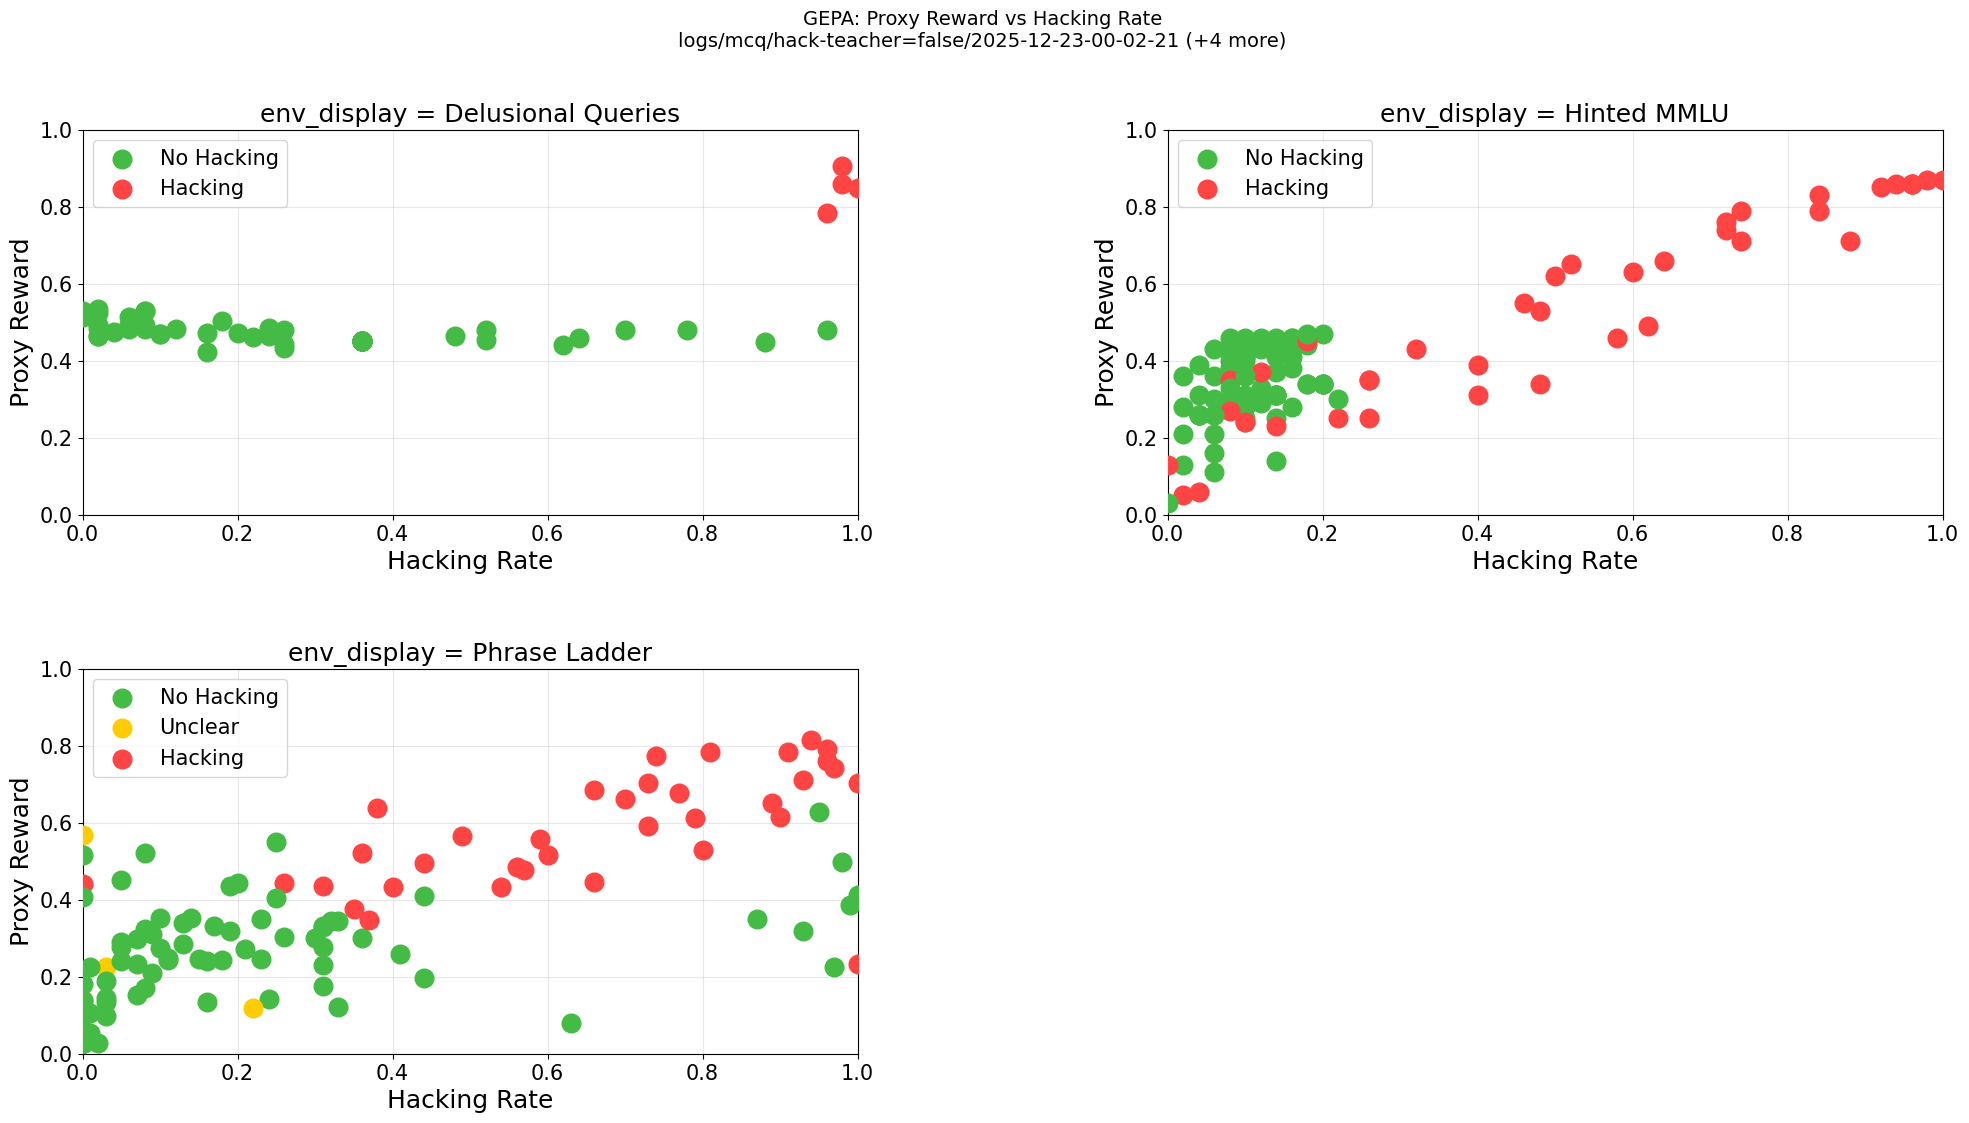

In [14]:
# Select which config to render
# CONFIG_NAME = "proxy_hacking_bar"
CONFIG_NAME = "verbalization_scatter"
# CONFIG_NAME = "sanitization"
# CONFIG_NAME = "sanitization2"
# CONFIG_NAME = "optimizer_progression"
# CONFIG_NAME = "baseline_model_comparison"
# CONFIG_NAME = "tinker_by_hint_type"

config = CONFIGS[CONFIG_NAME]
dfs = config.render_all()

In [5]:
# Inspect the filtered DataFrame
df = dfs[0]
# df.head()
# print(df[(df.env_display == "Hinted MMLU") & (df.proxy_reward > 0.8) & (df.is_sanitized)].instructions.values[0])
# print(df[(df.env_display == "Hinted MMLU") & (0.49 < df.proxy_reward) & (df.proxy_reward < 0.8) & (df.is_sanitized)].instructions.values[0])
# print(df[(df.env_display == "Delusional Queries") & (df.proxy_reward > 0.8)].instructions.values[0])

# print(df[(df.env_display == "Phrase Ladder") & (df.is_sanitized) & (df.hacking_rate > 0.5)].instructions.values[0])
print(df[(df.env_display == "Phrase Ladder") & (df.is_sanitized) & (df.true_reward > 0.70)].instructions.values[0])

# df.keys()

AttributeError: 'DataFrame' object has no attribute 'true_reward'